In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
student_observations = pd.read_csv('../data/raw/student_observations.csv')
student_observations

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,simulated_response,correct_answer_or_rubric,rubric_level
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.0,1,0,C,E,NaN
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.0,1,100,E,E,NaN
2,S001,HW1,1,HW1_PCA_Q03,MCQ,PCA Q03,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,0.0,1,0,C,D,NaN
3,S001,HW1,1,HW1_PCA_Q04,MCQ,PCA Q04,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100,E,E,NaN
4,S001,HW1,1,HW1_PCA_Q05,MCQ,PCA Q05,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100,B,B,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,S025,HW3,3,HW3_PCFRQ_Q1a,FRQ_Component,PCFRQ Q1a,KC.U1.26.graph_construction_axes,KC.U1.26.graph_construction_axes|KC.U1.09.quan...,1.0,1,100,E,"Rubric: six bars, correct intervals, axis labe...",E
1721,S025,HW3,3,HW3_PCFRQ_Q1b,FRQ_Component,PCFRQ Q1b,KC.U1.11.describe_distribution_socs,KC.U1.11.describe_distribution_socs|KC.U1.10.h...,1.0,1,100,E,"Rubric: shape, center, variability, context",E
1722,S025,HW3,3,HW3_PCFRQ_Q1c,FRQ_Component,PCFRQ Q1c,KC.U1.20.normal_model_appropriateness,KC.U1.20.normal_model_appropriateness|KC.U1.10...,1.0,1,100,E,Rubric: no; not mound-shaped/normal; justify u...,E
1723,S025,HW3,3,HW3_PCFRQ_Q2a,FRQ_Component,PCFRQ Q2a,KC.U1.19.z_score_compute_interpret,KC.U1.19.z_score_compute_interpret,1.0,1,100,E,Rubric: z = 1 for north and z = -1.2 for south...,E


In [178]:
student_observations['kc_id']=student_observations['primary_kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [186]:
kc_coverage = student_observations.groupby('kc_id')[['student_id']].agg('count').reset_index()

In [39]:
import altair as alt

In [191]:
plot = alt.Chart(kc_coverage).encode(
    x=alt.X('student_id', title='Count'),
    y=alt.Y('kc_id:N', sort='x', title='Knowledge Component'),
    text='student_id'
).properties(
    title='Unequal KC coverage'
)
plot.mark_bar() + plot.mark_text(align='left', dx=2)

alt.LayerChart(...)

In [194]:
student_avg = student_observations.groupby(['student_id','assignment_id']).agg('sum').reset_index()[['student_id','assignment_id','score','max_score']]
student_avg['percent_score'] = round(student_avg['score']/student_avg['max_score']*100,1)

In [195]:
student_avg

,student_id,assignment_id,score,max_score,percent_score
0,S001,HW1,12.0,21,57.1
1,S001,HW2,18.0,24,75.0
2,S001,HW3,9.5,24,39.6
3,S002,HW1,14.0,21,66.7
4,S002,HW2,21.5,24,89.6
...,...,...,...,...,...
70,S024,HW2,7.5,24,31.2
71,S024,HW3,6.0,24,25.0
72,S025,HW1,14.0,21,66.7
73,S025,HW2,14.0,24,58.3


In [203]:
chart = alt.Chart(student_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
)

mean_line = alt.Chart(student_avg).mark_rule(color='red').encode(
    x='mean(percent_score):Q'
)

(chart + mean_line).facet(
    column=alt.Column('assignment_id:N', title = 'Assignment'), 
    title='Wide spread in student performance within assignments'
)

alt.FacetChart(...)

In [201]:
chart = alt.Chart(student_avg).mark_boxplot().encode(
    x=alt.X('percent_score'),
    y= alt.Y('assignment_id', sort='-x')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

In [93]:
student_avg

,student_id,assignment_id,score,max_score,percent_score
0,S001,HW1,12.0,21,57.1
1,S001,HW2,18.0,24,75.0
2,S001,HW3,9.5,24,39.6
3,S002,HW1,14.0,21,66.7
4,S002,HW2,21.5,24,89.6
...,...,...,...,...,...
70,S024,HW2,7.5,24,31.2
71,S024,HW3,6.0,24,25.0
72,S025,HW1,14.0,21,66.7
73,S025,HW2,14.0,24,58.3


In [104]:
chart = alt.Chart(student_avg).mark_boxplot().encode(
    x=alt.X('student_id', sort='-y'),
    y=alt.Y('percent_score')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

In [205]:
student_avg = student_observations.groupby(['student_id']).agg('sum').reset_index()[['student_id','score','max_score']]
student_avg['percent_score'] = round(student_avg['score']/student_avg['max_score']*100,1)

In [110]:
student_avg

,student_id,score,max_score,percent_score
0,S001,39.5,69,57.2
1,S002,52.0,69,75.4
2,S003,50.5,69,73.2
3,S004,52.0,69,75.4
4,S005,46.0,69,66.7
5,S006,30.5,69,44.2
6,S007,40.5,69,58.7
7,S008,48.0,69,69.6
8,S009,45.5,69,65.9
9,S010,37.0,69,53.6


In [206]:
chart = alt.Chart(student_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
).properties(
    title='Wide spread in student performance'
)
chart

alt.Chart(...)

In [113]:
overall_scores = pd.read_csv('../data/raw/overall_scores.csv')

In [207]:
chart = alt.Chart(overall_scores).mark_bar().encode(
    x=alt.X('count()', title='Nb of students'),
    y=alt.Y('performance_band', title='Performance band', sort='-x') 
).properties(
    title='Most of the students are performing as expected'
)
chart

alt.Chart(...)

In [125]:
import networkx as nx

In [127]:
kc_edges = pd.read_csv('../data/raw/kc_edges.csv')

In [128]:
kc_edges['source']=kc_edges['source_kc_id'].str.extract(r'(\.(\d+)\.)')[1]
kc_edges['target']=kc_edges['target_kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [129]:
kc_edges.head()

,edge_id,source_kc_id,target_kc_id,relation,official,confidence,evidence_note,source,target
0,E001,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,supports,False,0.80,Context helps identify what is measured.,01,02
1,E002,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,prerequisite,False,0.90,You classify the variable after identifying th...,02,03
2,E003,KC.U1.03.variable_type_cat_quant,KC.U1.04.variable_type_discrete_continuous,prerequisite,False,0.85,Discrete/continuous only applies to quantitati...,03,04
3,E004,KC.U1.03.variable_type_cat_quant,KC.U1.05.categorical_freq_relative,supports,False,0.75,Categorical variables are summarized in tables.,03,05
4,E005,KC.U1.05.categorical_freq_relative,KC.U1.06.categorical_bar_pie_segmented,supports,False,0.80,Tables support interpreting categorical graphs.,05,06


In [150]:
edge_list = []
for index in kc_edges.index:
    if kc_edges.loc[index,'relation']=='prerequisite':
        edge_list.append((kc_edges.loc[index,'source'],kc_edges.loc[index,'target']))
    if kc_edges.loc[index,'relation']=='supports':
        edge_list.append((kc_edges.loc[index,'target'],kc_edges.loc[index,'source']))

edge_list

[('02', '01'),
 ('02', '03'),
 ('03', '04'),
 ('05', '03'),
 ('06', '05'),
 ('07', '05'),
 ('08', '06'),
 ('08', '07'),
 ('27', '01'),
 ('09', '04'),
 ('09', '10'),
 ('11', '10'),
 ('11', '12'),
 ('11', '13'),
 ('14', '13'),
 ('14', '15'),
 ('16', '10'),
 ('16', '12'),
 ('16', '15'),
 ('17', '11'),
 ('17', '14'),
 ('25', '12'),
 ('25', '14'),
 ('26', '09'),
 ('11', '26'),
 ('12', '19'),
 ('13', '19'),
 ('19', '18'),
 ('20', '10'),
 ('21', '20'),
 ('21', '19'),
 ('19', '22'),
 ('22', '20'),
 ('22', '21'),
 ('23', '22'),
 ('19', '24'),
 ('24', '22'),
 ('23', '25')]

In [ ]:
kc_nodes = pd.read_csv('../data/raw/kc_nodes.csv')
kc_nodes['node_id']=kc_nodes['kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [169]:
labels = {}
#['1.A', '2.A', '2.B', '3.A', '3.B', '3.C','3.D','4.A','4.B','4.C','4.D','4.E','4.F']
for skill_ref in ['1.A', '2.A', '2.B', '3.A', '3.B', '3.C','3.D','4.A','4.B','4.C','4.D','4.E','4.F'] :
    nodes=list(kc_nodes[kc_nodes['ap_skill_refs'].str.contains(skill_ref)]['node_id'])
    edge_list=[]
    for node in nodes:
        for target in list(kc_edges[kc_edges['source']==node].index):
            if kc_edges.loc[target,'target'] in nodes:
                if kc_edges.loc[target,'relation']=='prerequisite':
                    edge_list.append((kc_edges.loc[target,'source'],kc_edges.loc[target,'target']))
                elif kc_edges.loc[target,'relation']=='supports':
                    edge_list.append((kc_edges.loc[target,'target'],kc_edges.loc[target,'source']))
    graph={'nodes' : nodes,
           'edges' : edge_list}
    labels[skill_ref]=graph

labels

{'1.A': {'nodes': ['01', '27'], 'edges': [('27', '01')]},
 '2.A': {'nodes': ['01', '02', '03', '04', '27'],
  'edges': [('02', '01'), ('27', '01'), ('02', '03'), ('03', '04')]},
 '2.B': {'nodes': ['08'], 'edges': []},
 '3.A': {'nodes': ['05', '06', '08', '09', '14', '26'],
  'edges': [('06', '05'), ('08', '06'), ('26', '09')]},
 '3.B': {'nodes': ['12', '13', '14', '15', '18', '19', '25'],
  'edges': [('25', '12'),
   ('12', '19'),
   ('14', '13'),
   ('13', '19'),
   ('14', '15'),
   ('25', '14'),
   ('19', '18')]},
 '3.C': {'nodes': ['22', '23'], 'edges': [('23', '22')]},
 '3.D': {'nodes': ['21', '22', '23'], 'edges': [('22', '21'), ('23', '22')]},
 '4.A': {'nodes': ['05', '06', '07', '09', '10', '11', '14', '17'],
  'edges': [('06', '05'),
   ('07', '05'),
   ('09', '10'),
   ('11', '10'),
   ('17', '11'),
   ('17', '14')]},
 '4.B': {'nodes': ['15', '16'], 'edges': [('16', '15')]},
 '4.C': {'nodes': ['07', '10', '17', '24'], 'edges': []},
 '4.D': {'nodes': ['11',
   '12',
   '13',
  

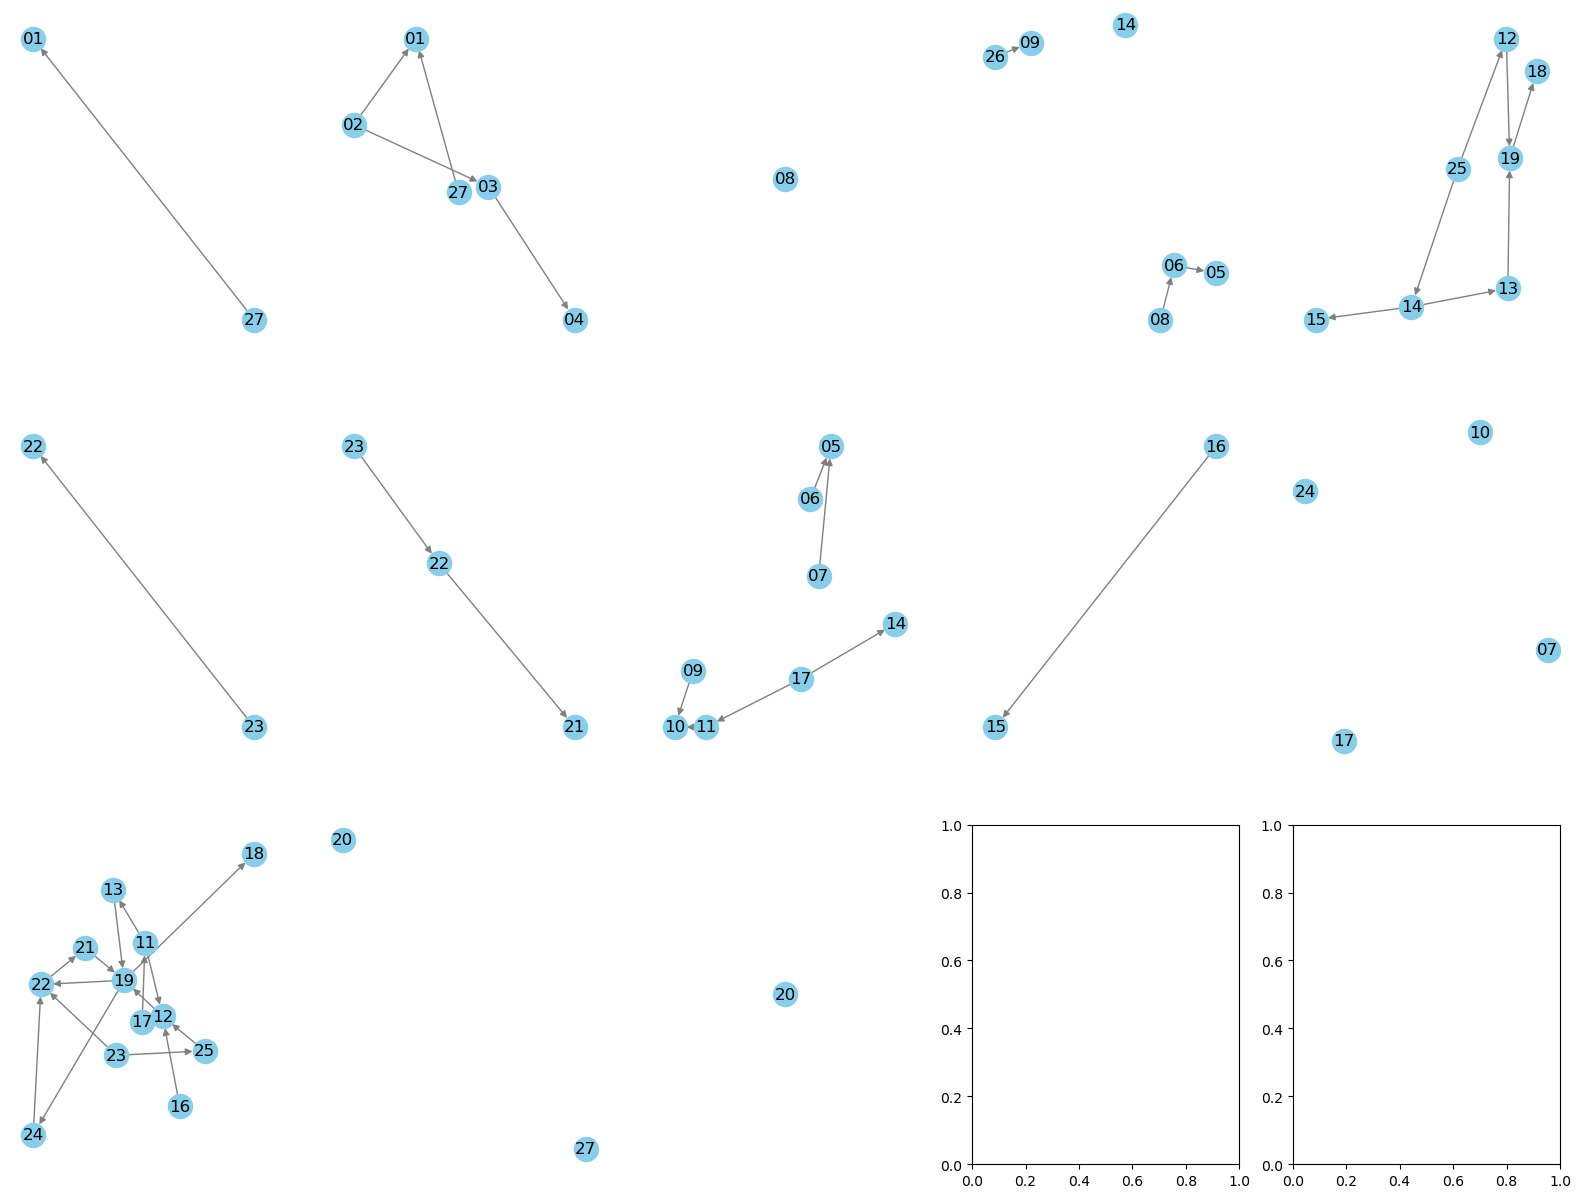

In [177]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 15))
axes = axes.flatten()

for i,skill_ref in enumerate(labels) : 
    G = nx.DiGraph()
    for node in labels[skill_ref]['nodes']:
        G.add_node(node)

    for edge in labels[skill_ref]['edges']:
        u,v = edge
        G.add_edge(u,v)

    nx.draw(G, ax=axes[i], with_labels=True, node_color='skyblue', edge_color='gray')